# 28 · Qwen3-14B frontier review

AWS-only aggregate review of the completed 14B capacity/diversity study. No private rows, model weights, AWS credentials, or Kaggle calls are required.

,System,Policy-macro AUC,Pooled AUC
2,blend_50_50,0.730175,0.748871
0,qwen4b,0.719893,0.738959
1,qwen14b,0.708455,0.722877


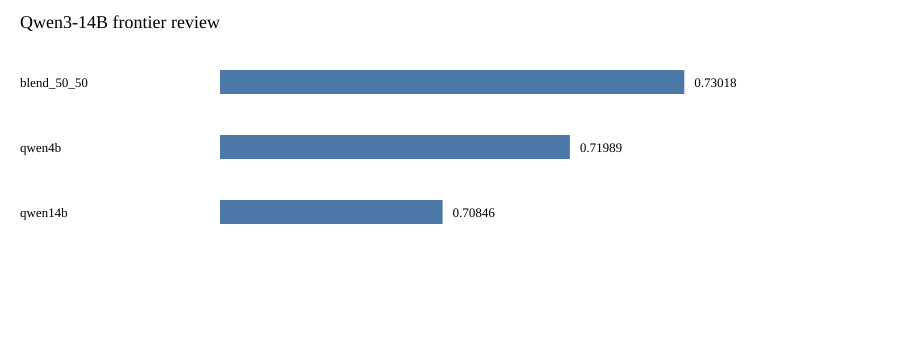

PLOTLY_AND_SVG_RENDERED


In [1]:
from pathlib import Path
import json
import pandas as pd
import plotly.graph_objects as go
from IPython.display import SVG, display

ROOT = Path.cwd()
while not (ROOT / "reports/checkpoints/qwen14b_frontier.json").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("Repository root not found")
    ROOT = ROOT.parent

record = json.loads((ROOT / "reports/checkpoints/qwen14b_frontier.json").read_text())
metrics = record["development_result"]["metrics"]
rows = []
for model, values in metrics.items():
    rows.append({
        "System": model,
        "Policy-macro AUC": values["rule_macro_auc"],
        "Pooled AUC": values["pooled_auc"],
    })
frame = pd.DataFrame(rows).sort_values("Policy-macro AUC", ascending=False)
display(frame)

fig = go.Figure(go.Bar(
    x=frame["Policy-macro AUC"],
    y=frame["System"],
    orientation="h",
    text=frame["Policy-macro AUC"].map(lambda x: f"{x:.5f}"),
    textposition="outside",
))
fig.update_layout(
    template="none",
    title="Qwen3-14B adds ensemble diversity, not standalone dominance",
    height=340,
    margin=dict(l=210, r=80, t=75, b=55),
    xaxis_title="Equal-weight policy-macro ROC AUC",
    yaxis=dict(autorange="reversed", automargin=True),
    showlegend=False,
)
display(fig)

values = frame["Policy-macro AUC"].tolist()
labels = frame["System"].tolist()
low, high = min(values) - 0.02, max(values) + 0.005
parts = ['<svg xmlns="http://www.w3.org/2000/svg" width="900" height="340">']
parts.append('<text x="20" y="28" font-size="18">Qwen3-14B frontier review</text>')
for i, (label, value) in enumerate(zip(labels, values)):
    y = 70 + 65 * i
    width = 520 * (value - low) / max(1e-9, high - low)
    parts.append(f'<text x="20" y="{y+17}" font-size="13">{label}</text>')
    parts.append(f'<rect x="220" y="{y}" width="{width:.1f}" height="24" fill="#4C78A8"/>')
    parts.append(f'<text x="{230+width:.1f}" y="{y+17}" font-size="13">{value:.5f}</text>')
parts.append('</svg>')
display(SVG("".join(parts)))
print("PLOTLY_AND_SVG_RENDERED")

In [2]:
gain = record["development_result"]["blend_gain_vs_qwen4b"]
interval = record["development_result"]["uncertainty"]["blend_minus_4b"]
print(f"Fixed 4B+14B blend gain: {gain:+.6f} policy-macro AUC")
print(f"Grouped-bootstrap 95% interval: [{interval['lower_95']:.5f}, {interval['upper_95']:.5f}]")
print("Standalone 14B promoted:", record["development_result"]["decision"]["qwen14b_positive"])
print("Private leaderboard score used for selection:", record["development_result"]["decision"]["private_score_used_for_selection"])
print("FOLLOWING_CELL_EXECUTED")

Fixed 4B+14B blend gain: +0.010282 policy-macro AUC
Grouped-bootstrap 95% interval: [-0.00429, 0.02450]
Standalone 14B promoted: False
Private leaderboard score used for selection: False
FOLLOWING_CELL_EXECUTED


## Interpretation

The standalone 14B model is weaker on this repeatedly examined two-policy cohort, while the fixed 4B+14B rank blend improves both observed policies. The interval crosses zero, so the result motivates ensemble research rather than a standalone 14B promotion or a claim of leaderboard improvement.